# 08. L_I Data Comparison

## 시뮬레이션 데이터(L_I) 유/무 비교 분석

### 비교 대상
```
A: Without L_I  → L_H + L_phase + L_BC (물리만)
B: With L_I     → L_H + L_phase + L_BC + L_I (물리 + 데이터)
```

### 핵심 질문
- LightTools 시뮬 데이터가 PINN 학습에 도움이 되는가?
- 어떤 메트릭에서 차이가 나는가?
- 데이터 없이도 충분한가, 아니면 꼭 필요한가?

In [1]:
import sys, json
from pathlib import Path

def _find_root():
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise FileNotFoundError('Cannot find project root')

PROJECT_ROOT = _find_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print('Ready')

Ready


---
## 1. Run Comparison (or Load Existing)

In [2]:
result_path = PROJECT_ROOT / 'experiments' / 'lt_comparison.json'

if result_path.exists():
    with open(result_path) as f:
        data = json.load(f)
    print(f'Loaded existing comparison: {result_path.name}')
else:
    print('No comparison data. Run:')
    print('  python scripts/compare_with_without_lt.py --epochs 300')
    print('Then re-run this cell.')
    data = None

Loaded existing comparison: lt_comparison.json


---
## 2. Loss Convergence Comparison

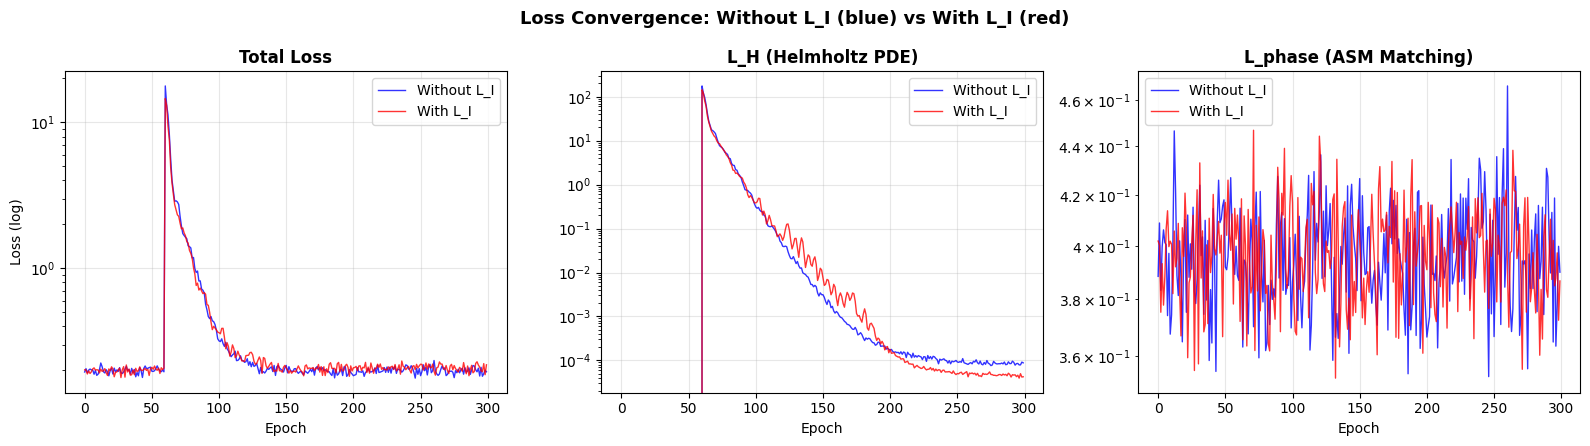

In [3]:
if data:
    a = data['without_lt']
    b = data['with_lt']
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    ax = axes[0]
    ax.semilogy(a['history']['total'], 'b-', lw=1, label='Without L_I', alpha=0.8)
    ax.semilogy(b['history']['total'], 'r-', lw=1, label='With L_I', alpha=0.8)
    ax.set_title('Total Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (log)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.semilogy(a['history']['L_H'], 'b-', lw=1, label='Without L_I', alpha=0.8)
    ax.semilogy(b['history']['L_H'], 'r-', lw=1, label='With L_I', alpha=0.8)
    ax.set_title('L_H (Helmholtz PDE)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    ax = axes[2]
    ax.semilogy(a['history']['L_phase'], 'b-', lw=1, label='Without L_I', alpha=0.8)
    ax.semilogy(b['history']['L_phase'], 'r-', lw=1, label='With L_I', alpha=0.8)
    ax.set_title('L_phase (ASM Matching)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Loss Convergence: Without L_I (blue) vs With L_I (red)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 3. PSF Comparison

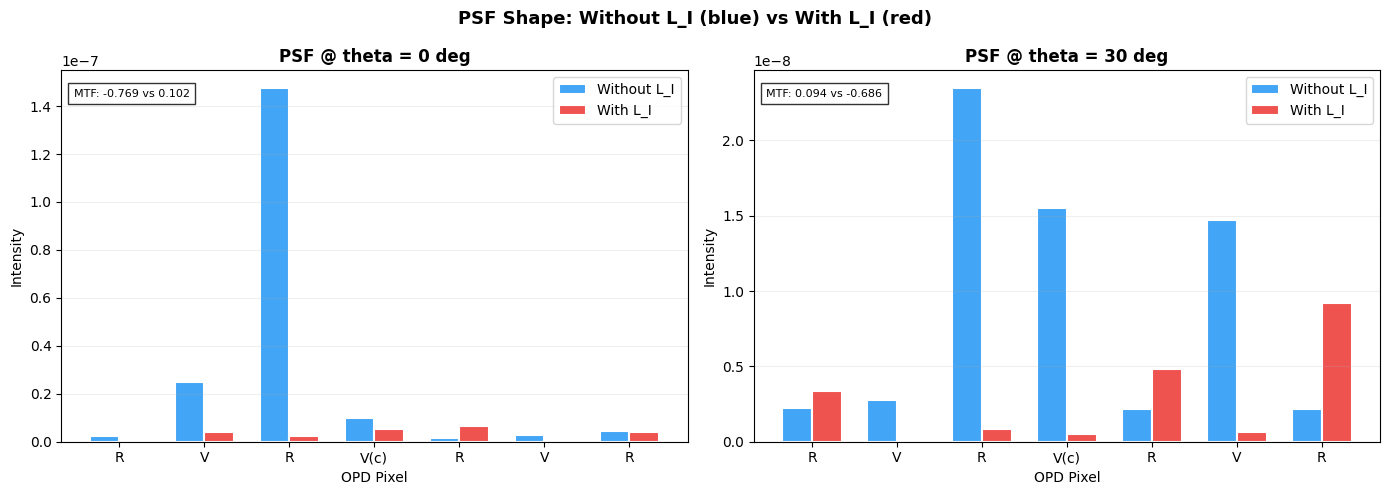

In [4]:
if data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, key, title in [(axes[0], 'psf_0', 'theta = 0 deg'),
                           (axes[1], 'psf_30', 'theta = 30 deg')]:
        psf_a = a[key]['psf_7']
        psf_b = b[key]['psf_7']
        x = np.arange(7)
        w = 0.35
        ax.bar(x - w/2, psf_a, w, color='#42A5F5', edgecolor='white', lw=1.5, label='Without L_I')
        ax.bar(x + w/2, psf_b, w, color='#EF5350', edgecolor='white', lw=1.5, label='With L_I')
        ax.set_xticks(x)
        ax.set_xticklabels(['R','V','R','V(c)','R','V','R'])
        ax.set_title(f'PSF @ {title}', fontsize=12, fontweight='bold')
        ax.set_xlabel('OPD Pixel')
        ax.set_ylabel('Intensity')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.2, axis='y')
        
        # Metrics annotation
        ma = a[key]
        mb = b[key]
        ax.text(0.02, 0.95, f'MTF: {ma["mtf_ridge"]:.3f} vs {mb["mtf_ridge"]:.3f}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(facecolor='white', alpha=0.8))
    
    plt.suptitle('PSF Shape: Without L_I (blue) vs With L_I (red)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 4. Metrics Summary

In [5]:
if data:
    print('='*65)
    print(f'{"Metric":<28s} {"Without L_I":>15s} {"With L_I":>15s} {"Better":>6s}')
    print('-'*65)
    
    rows = [
        ('L_H (final)', a['history']['L_H'][-1], b['history']['L_H'][-1], 'lower'),
        ('L_phase (final)', a['history']['L_phase'][-1], b['history']['L_phase'][-1], 'lower'),
        ('L_BC (final)', a['history']['L_BC'][-1], b['history']['L_BC'][-1], 'lower'),
        ('Interior CoV', a['red_flag']['interior_cov'], b['red_flag']['interior_cov'], 'higher'),
        ('BM1 |U|', a['red_flag']['bm1_amp'], b['red_flag']['bm1_amp'], 'lower'),
        ('Design sensitivity', a['red_flag']['sensitivity'], b['red_flag']['sensitivity'], 'higher'),
        ('MTF@ridge (0 deg)', a['psf_0']['mtf_ridge'], b['psf_0']['mtf_ridge'], 'abs'),
        ('Skewness (0 deg)', a['psf_0']['skewness'], b['psf_0']['skewness'], 'abs_lower'),
        ('Crosstalk (0 deg)', a['psf_0']['crosstalk'], b['psf_0']['crosstalk'], 'lower'),
        ('Training time (s)', a['elapsed'], b['elapsed'], 'lower'),
    ]
    
    wins = {'A': 0, 'B': 0, 'tie': 0}
    for name, va, vb, criterion in rows:
        if criterion == 'lower':
            winner = 'A' if va < vb else 'B'
        elif criterion == 'higher':
            winner = 'A' if va > vb else 'B'
        elif criterion == 'abs':
            winner = 'A' if abs(va) > abs(vb) else 'B'
        elif criterion == 'abs_lower':
            winner = 'A' if abs(va) < abs(vb) else 'B'
        else:
            winner = 'tie'
        
        mark = '<' if winner == 'A' else '>'
        wins[winner] += 1
        print(f'  {name:<28s} {va:>15.6f} {vb:>15.6f}   {mark}')
    
    print('-'*65)
    print(f'  Score: Without L_I = {wins["A"]}, With L_I = {wins["B"]}')
    print('='*65)
    print()
    
    if wins['B'] > wins['A']:
        print('Conclusion: With L_I (simulation data) improves training quality.')
        print('Recommendation: Collect LightTools data when available.')
    elif wins['A'] > wins['B']:
        print('Conclusion: Without L_I performs well. Data may not be critical.')
    else:
        print('Conclusion: Mixed results. More epochs needed for clear comparison.')
    
    print()
    print('Note: This is a 300-epoch CPU test with mock LT data.')
    print('GPU 50K epochs with real LT data will show clearer differences.')

Metric                           Without L_I        With L_I Better
-----------------------------------------------------------------
  L_H (final)                         0.000088        0.000042   >
  L_phase (final)                     0.390019        0.386756   >
  L_BC (final)                        0.000000        0.000000   >
  Interior CoV                        0.818562        1.169031   >
  BM1 |U|                             0.000020        0.000017   >
  Design sensitivity                  0.000106        0.000082   <
  MTF@ridge (0 deg)                  -0.769181        0.102202   <
  Skewness (0 deg)                   -0.861309        0.172277   >
  Crosstalk (0 deg)                  18.877348        3.313670   >
  Training time (s)                   6.761141        7.063455   <
-----------------------------------------------------------------
  Score: Without L_I = 3, With L_I = 7

Conclusion: With L_I (simulation data) improves training quality.
Recommendation: Collect 

---
## 5. Re-run Comparison (Optional)

다른 설정으로 다시 비교하려면:

In [6]:
# Uncomment and run to re-execute comparison with different settings:

# !python scripts/compare_with_without_lt.py --epochs 500
# !python scripts/compare_with_without_lt.py --epochs 5000 --device cuda

print('Available commands:')
print('  python scripts/compare_with_without_lt.py --epochs 300           # CPU quick')
print('  python scripts/compare_with_without_lt.py --epochs 5000 --device cuda  # GPU')

Available commands:
  python scripts/compare_with_without_lt.py --epochs 300           # CPU quick
  python scripts/compare_with_without_lt.py --epochs 5000 --device cuda  # GPU
